In [49]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.stats import t
from scipy.stats import jarque_bera

df = pd.read_excel("/users/apple/downloads/OLS_and_ML_40.xlsx")

df

,Y,X1
0,31.847416,8.520947
1,10.728718,5.569246
2,23.295895,7.374137
3,31.469251,7.977606
4,33.547873,8.693558
...,...,...
1495,3.204838,4.698854
1496,14.752273,6.849772
1497,22.328102,7.452918
1498,0.330768,1.525998


In [51]:
X = sm.add_constant(df['X1'])
y = df['Y']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     3572.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        21:26:24   Log-Likelihood:                -5219.3
No. Observations:                1500   AIC:                         1.044e+04
Df Residuals:                    1498   BIC:                         1.045e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.5145      0.415    -15.695      0.000      -7.329      -5.700
X1             4.1792      0.070     59.766      0.000       4.042       4.316
==============================================================================
Omnibus:                      154.736   Durbin-Watson:                   2.131
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              108.685
Skew:                           0.550   Prob(JB):                     2.51e-24
Kurtosis:                       2.273   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 2.i Ramsey RESET 1

In [52]:
y_hat = model.fittedvalues

y_hat.head()

X_reset = pd.DataFrame({
    'const': 1,
    'X1': df['X1'],
    'yhat_sq': y_hat**2
})

reset_model = sm.OLS(y, X_reset).fit()

reset_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 2.873e+04
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        21:26:31   Log-Likelihood:                -3378.6
No. Observations:                1500   AIC:                             6763.
Df Residuals:                    1497   BIC:                             6779.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1035      0.168     48.230      0.000       7.774       8.433
X1            -2.7840      0.059    -47.295      0.000      -2.899      -2.669
yhat_sq        0.0571      0.000    126.196      0.000       0.056       0.058
==============================================================================
Omnibus:                       72.525   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              226.601
Skew:                           0.132   Prob(JB):                     6.23e-50
Kurtosis:                       4.886   Cond. No.                     1.57e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.57e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [53]:
t_stat = reset_model.tvalues['yhat_sq']
p_value = reset_model.pvalues['yhat_sq']

print("Ramsey RESET test result:")
print(f"t-statistic = {t_stat}")
print(f"p-value = {p_value}")

Ramsey RESET test result:
t-statistic = 126.1957808849966
p-value = 0.0


# 2.j Ramsey RESET 2

In [54]:
df['X1_sq'] = df['X1']**2

X_quad = sm.add_constant(df[['X1', 'X1_sq']])
y = df['Y']

model_quad = sm.OLS(y, X_quad).fit()
model_quad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 2.873e+04
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        21:26:41   Log-Likelihood:                -3378.6
No. Observations:                1500   AIC:                             6763.
Df Residuals:                    1497   BIC:                             6779.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5248      0.182     57.899      0.000      10.168      10.881
X1            -5.8906      0.082    -71.499      0.000      -6.052      -5.729
X1_sq          0.9965      0.008    126.196      0.000       0.981       1.012
==============================================================================
Omnibus:                       72.525   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              226.601
Skew:                           0.132   Prob(JB):                     6.23e-50
Kurtosis:                       4.886   Cond. No.                         154.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
y_hat_quad = model_quad.fittedvalues

X_reset_quad = pd.DataFrame({
    'const': 1,
    'X1': df['X1'],
    'X1_sq': df['X1_sq'],
    'yhat_sq': y_hat_quad**2
})

reset_model_quad = sm.OLS(y, X_reset_quad).fit()
reset_model_quad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 1.916e+04
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        20:38:39   Log-Likelihood:                -3378.1
No. Observations:                1500   AIC:                             6764.
Df Residuals:                    1496   BIC:                             6785.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3799      0.229     45.266      0.000       9.930      10.830
X1            -5.7642      0.147    -39.166      0.000      -6.053      -5.476
X1_sq          0.9775      0.020     48.944      0.000       0.938       1.017
yhat_sq        0.0004      0.000      1.036      0.300      -0.000       0.001
==============================================================================
Omnibus:                       73.747   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              233.504
Skew:                           0.133   Prob(JB):                     1.97e-51
Kurtosis:                       4.915   Cond. No.                     3.56e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.56e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [55]:
t_stat = reset_model_quad.tvalues['yhat_sq']
p_value = reset_model_quad.pvalues['yhat_sq']

print("RESET test (quadratic model):")
print(f"t-statistic = {t_stat}")
print(f"p-value = {p_value}")

RESET test (quadratic model):
t-statistic = 1.0361679543789544
p-value = 0.30029124971218707


# 2.k JB test

In [56]:
residuals = model_quad.resid

jb_stat, p_value = jarque_bera(residuals)

print("Jarque-Bera test:")
print(f"JB statistic = {jb_stat}")
print(f"p-value = {p_value}")

Jarque-Bera test:
JB statistic = 226.60052176152612
p-value = 0.0


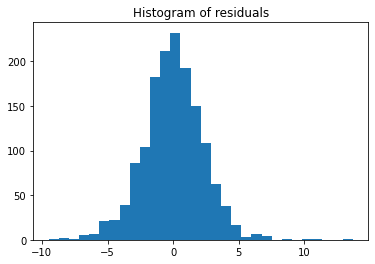

In [39]:
plt.hist(residuals, bins=30)
plt.title("Histogram of residuals")
plt.show()

# 2.k ML estimation

In [48]:
def neg_log_likelihood(params, y, x1):
    beta0, beta1, beta2, sigma, nu = params
    
    if sigma <= 0 or nu <= 2:
        return 1e10
    
    y_pred = beta0 + beta1 * x1 + beta2 * (x1**2)
    
    u = y - y_pred
    
    log_lik = t.logpdf(u, df=nu, loc=0, scale=sigma)
    
    return -np.sum(log_lik)

In [47]:
y = df['Y'].values
x1 = df['X1'].values

init_params = [
    model_quad.params['const'],
    model_quad.params['X1'],
    model_quad.params['X1_sq'],
    np.std(model_quad.resid),
    10  # we use 10 because we expect the value to be in between 5 and 15, and it has to be more than 2
]

result = minimize(
    neg_log_likelihood,
    init_params,
    args=(y, x1),
    method='L-BFGS-B'
)

params_hat = result.x

print("Estimated parameters:")
print(f"beta0 = {params_hat[0]}")
print(f"beta1 = {params_hat[1]}")
print(f"beta2 = {params_hat[2]}")
print(f"sigma = {params_hat[3]}")
print(f"nu = {params_hat[4]}")

Estimated parameters:
beta0 = 10.640449452174895
beta1 = -5.938621322576142
beta2 = 1.0003673795179238
sigma = 1.9530742183506766
nu = 7.191902302737937
